In [22]:
df = pd.read_csv('us_flights_2015_2024.csv')

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63079446 entries, 0 to 63079445
Data columns (total 11 columns):
 #   Column             Dtype  
---  ------             -----  
 0   YEAR               int64  
 1   MONTH              int64  
 2   DAY_OF_WEEK        int64  
 3   OP_UNIQUE_CARRIER  object 
 4   ORIGIN             object 
 5   DEST               object 
 6   CRS_DEP_TIME       int64  
 7   CRS_ARR_TIME       int64  
 8   CANCELLED          bool   
 9   CRS_ELAPSED_TIME   float64
 10  DISTANCE           float64
dtypes: bool(1), float64(2), int64(5), object(3)
memory usage: 4.8+ GB


Matplotlib is building the font cache; this may take a moment.


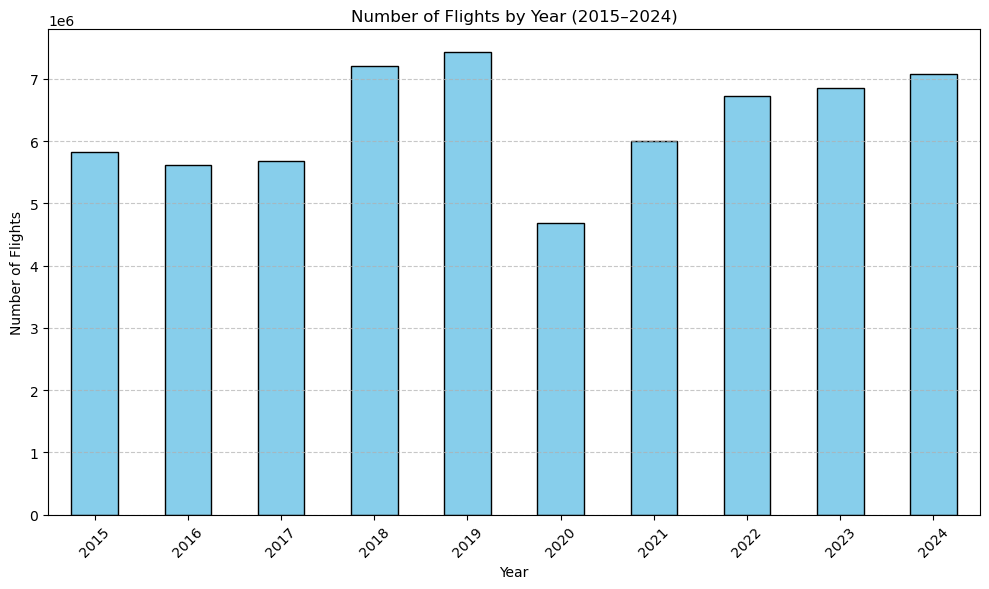

In [26]:
import matplotlib.pyplot as plt

# Group by year and count flights
flight_counts = df['YEAR'].value_counts().sort_index()

# Plot as bar chart
plt.figure(figsize=(10, 6))
flight_counts.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Number of Flights by Year (2015–2024)')
plt.xlabel('Year')
plt.ylabel('Number of Flights')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

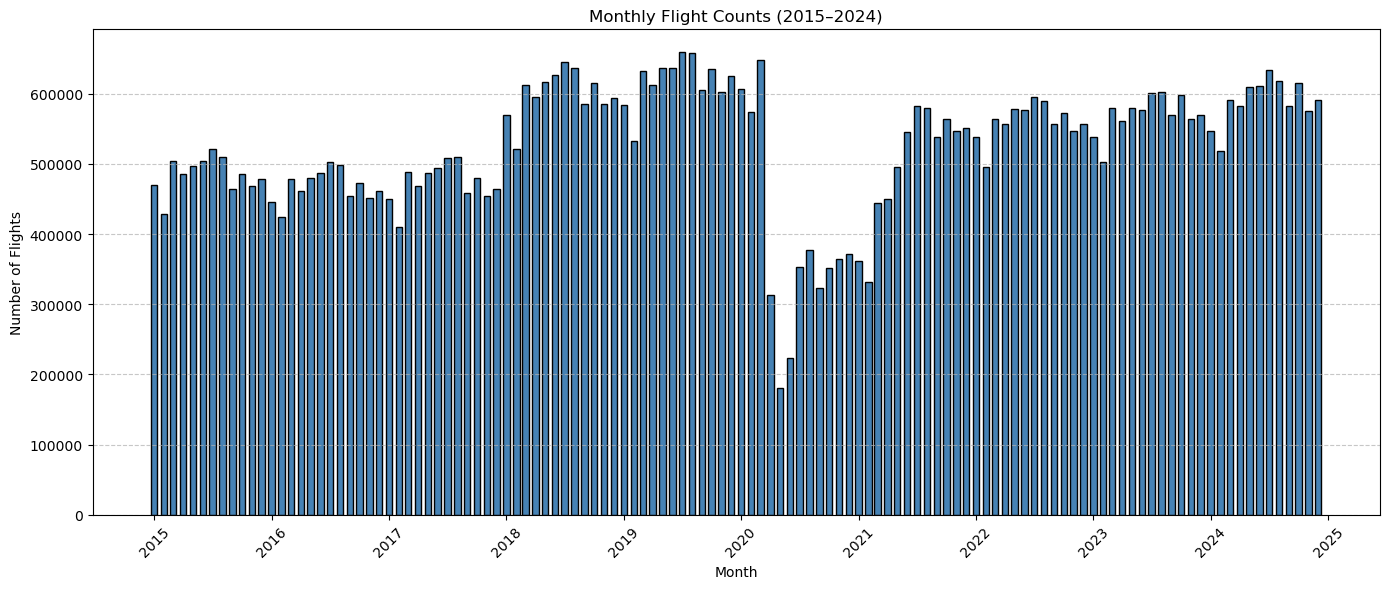

In [27]:
# Group by YEAR and MONTH, count flights
monthly_counts = df.groupby(['YEAR', 'MONTH']).size().reset_index(name='FlightCount')

# Create a datetime column for plotting
monthly_counts['Date'] = pd.to_datetime(monthly_counts['YEAR'].astype(str) + '-' + monthly_counts['MONTH'].astype(str))

# Sort by date
monthly_counts.sort_values('Date', inplace=True)

# Plot
plt.figure(figsize=(14, 6))
plt.bar(monthly_counts['Date'], monthly_counts['FlightCount'], width=20, color='steelblue', edgecolor='black')

plt.title('Monthly Flight Counts (2015–2024)')
plt.xlabel('Month')
plt.ylabel('Number of Flights')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

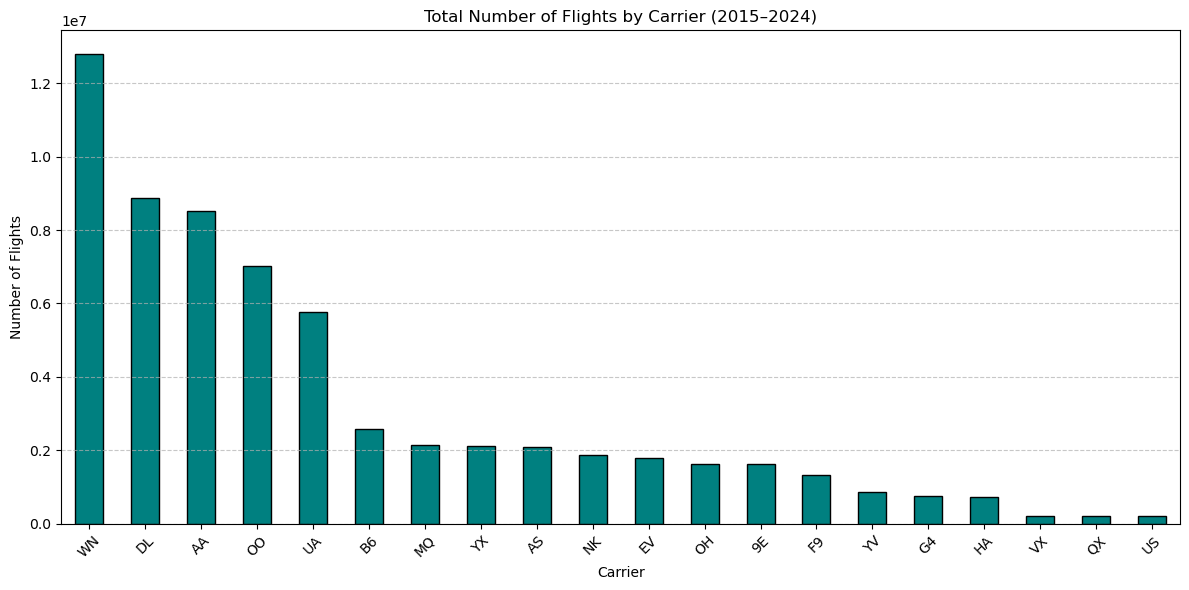

In [28]:
# Group by carrier and count flights
carrier_counts = df['OP_UNIQUE_CARRIER'].value_counts().sort_values(ascending=False)

# Plot
plt.figure(figsize=(12, 6))
carrier_counts.plot(kind='bar', color='teal', edgecolor='black')

plt.title('Total Number of Flights by Carrier (2015–2024)')
plt.xlabel('Carrier')
plt.ylabel('Number of Flights')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

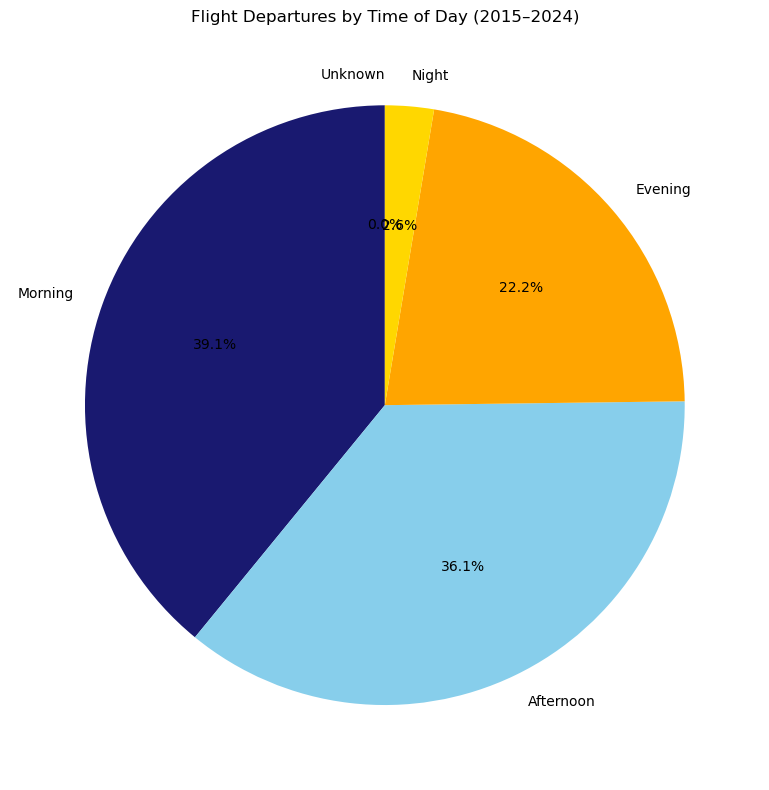

In [29]:
# Define time-of-day categories based on CRS_DEP_TIME (in HHMM format)
def classify_time(dep_time):
    if pd.isnull(dep_time):
        return 'Unknown'
    hour = int(dep_time // 100)
    if 0 <= hour < 6:
        return 'Night'
    elif 6 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 18:
        return 'Afternoon'
    else:
        return 'Evening'

# Apply classification
df['DeparturePeriod'] = df['CRS_DEP_TIME'].apply(classify_time)

# Count flights per period
period_counts = df['DeparturePeriod'].value_counts()

# Plot pie chart
plt.figure(figsize=(8, 8))
plt.pie(period_counts, labels=period_counts.index, autopct='%1.1f%%', startangle=90, colors=['midnightblue', 'skyblue', 'orange', 'gold'])
plt.title('Flight Departures by Time of Day (2015–2024)')
plt.tight_layout()
plt.show()

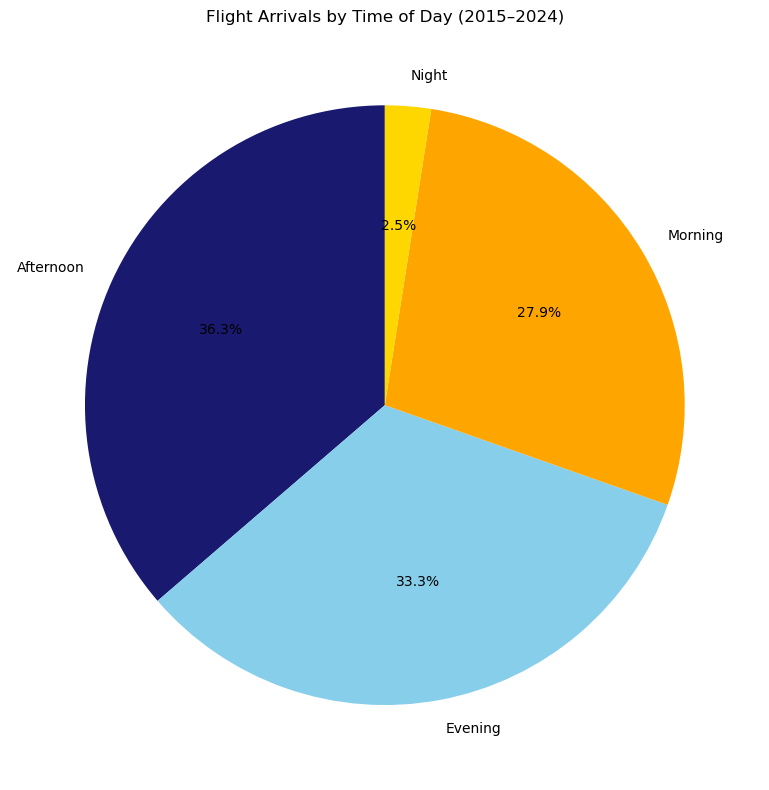

In [30]:
# Define time-of-day categories based on CRS_ARR_TIME (in HHMM format)
def classify_arrival_time(arr_time):
    if pd.isnull(arr_time):
        return 'Unknown'
    hour = int(arr_time // 100)
    if 0 <= hour < 6:
        return 'Night'
    elif 6 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 18:
        return 'Afternoon'
    else:
        return 'Evening'

# Apply classification
df['ArrivalPeriod'] = df['CRS_ARR_TIME'].apply(classify_arrival_time)

# Count flights per period
arrival_counts = df['ArrivalPeriod'].value_counts()

# Plot pie chart
plt.figure(figsize=(8, 8))
plt.pie(arrival_counts, labels=arrival_counts.index, autopct='%1.1f%%', startangle=90,
        colors=['midnightblue', 'skyblue', 'orange', 'gold'])
plt.title('Flight Arrivals by Time of Day (2015–2024)')
plt.tight_layout()
plt.show()

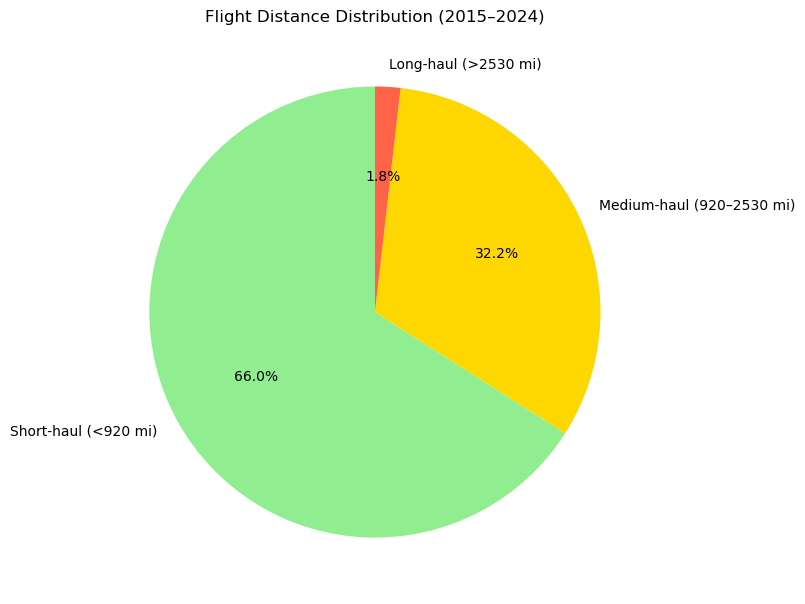

In [32]:
# Define distance categories
def classify_distance(miles):
    if pd.isnull(miles):
        return 'Unknown'
    elif miles < 920:
        return 'Short-haul (<920 mi)'
    elif 920 <= miles <= 2530:
        return 'Medium-haul (920–2530 mi)'
    else:
        return 'Long-haul (>2530 mi)'

# Apply classification
df['DistanceCategory'] = df['DISTANCE'].apply(classify_distance)

# Count flights per category
distance_counts = df['DistanceCategory'].value_counts()

# Plot pie chart
plt.figure(figsize=(8, 8))
plt.pie(distance_counts, labels=distance_counts.index, autopct='%1.1f%%', startangle=90,
        colors=['lightgreen', 'gold', 'tomato'])
plt.title('Flight Distance Distribution (2015–2024)')
plt.tight_layout()
plt.show()

In [33]:
# Select only int and float columns
num_cols = df.select_dtypes(include=['int8', 'int16', 'float32']).columns

# Check for nulls in these columns
null_summary = df[num_cols].isnull().sum()
print("Null values in numeric columns:\n", null_summary)

Null values in numeric columns:
 YEAR                  0
MONTH                 0
DAY_OF_WEEK           0
CRS_DEP_TIME          0
CRS_ARR_TIME          0
CRS_ELAPSED_TIME    176
DISTANCE              0
dtype: int64


In [34]:
# Fill nulls with zeros
df[num_cols] = df[num_cols].fillna(0)

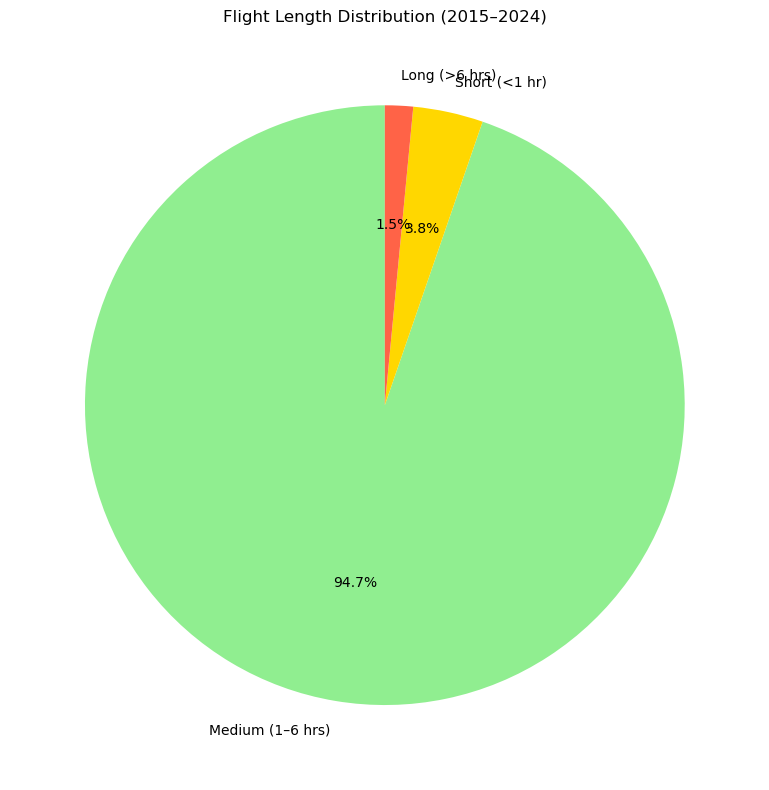

In [35]:
# Define flight length categories
def classify_flight_length(minutes):
    if pd.isnull(minutes):
        return 'Unknown'
    elif minutes < 60:
        return 'Short (<1 hr)'
    elif 60 <= minutes <= 360:
        return 'Medium (1–6 hrs)'
    else:
        return 'Long (>6 hrs)'

# Apply classification
df['FlightLength'] = df['CRS_ELAPSED_TIME'].apply(classify_flight_length)

# Count flights per category
length_counts = df['FlightLength'].value_counts()

# Plot pie chart
plt.figure(figsize=(8, 8))
plt.pie(length_counts, labels=length_counts.index, autopct='%1.1f%%', startangle=90,
        colors=['lightgreen', 'gold', 'tomato'])
plt.title('Flight Length Distribution (2015–2024)')
plt.tight_layout()
plt.show()

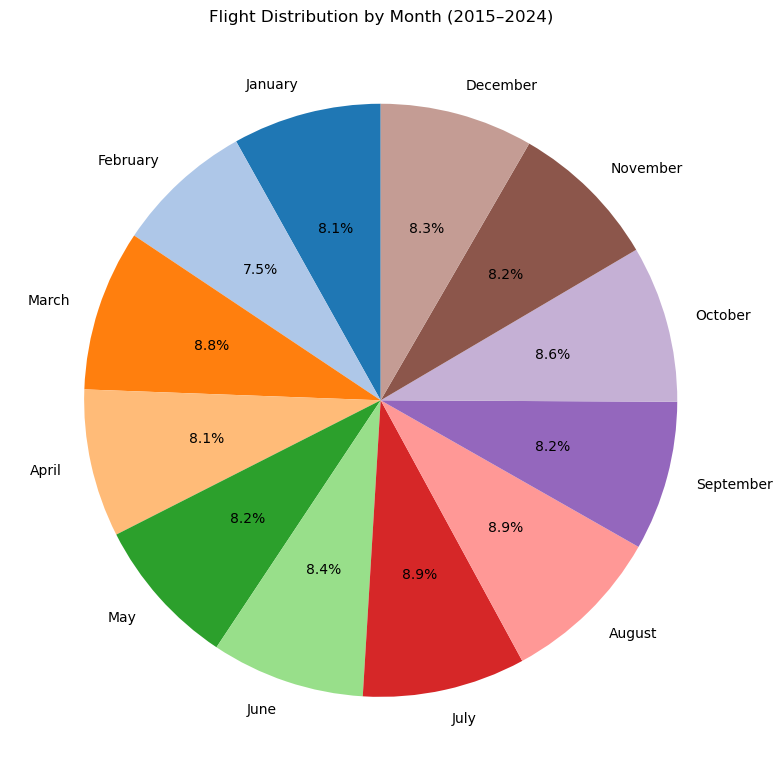

In [36]:
# Count flights by month (across all years)
month_counts = df['MONTH'].value_counts().sort_index()

# Optional: map month numbers to names
month_names = {
    1: 'January', 2: 'February', 3: 'March', 4: 'April',
    5: 'May', 6: 'June', 7: 'July', 8: 'August',
    9: 'September', 10: 'October', 11: 'November', 12: 'December'
}
month_counts.index = month_counts.index.map(month_names)

# Plot pie chart
plt.figure(figsize=(8, 8))
plt.pie(month_counts, labels=month_counts.index, autopct='%1.1f%%', startangle=90,
        colors=plt.cm.tab20.colors)
plt.title('Flight Distribution by Month (2015–2024)')
plt.tight_layout()
plt.show()

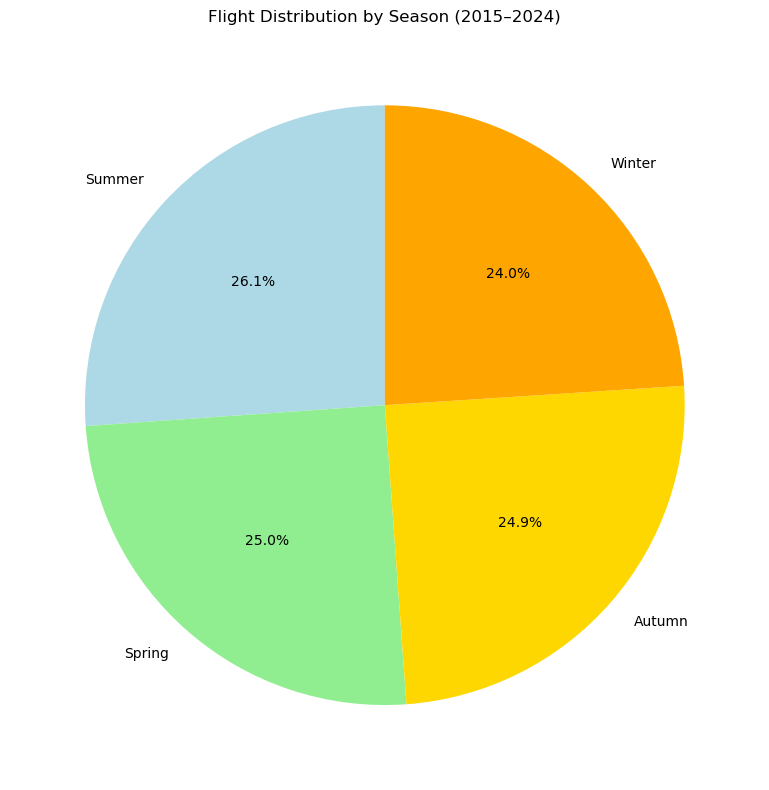

In [37]:
# Define seasons based on month
def classify_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    elif month in [9, 10, 11]:
        return 'Autumn'
    else:
        return 'Unknown'

# Apply classification
df['Season'] = df['MONTH'].apply(classify_season)

# Count flights per season
season_counts = df['Season'].value_counts()

# Plot pie chart
plt.figure(figsize=(8, 8))
plt.pie(season_counts, labels=season_counts.index, autopct='%1.1f%%', startangle=90,
        colors=['lightblue', 'lightgreen', 'gold', 'orange'])
plt.title('Flight Distribution by Season (2015–2024)')
plt.tight_layout()
plt.show()

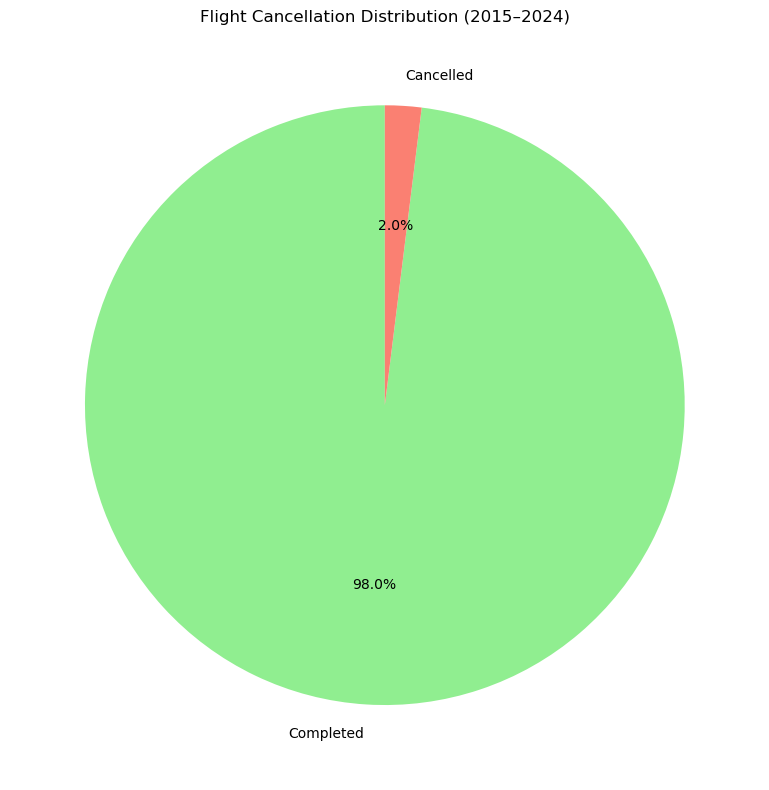

In [40]:
# Step 1: Map boolean values to readable labels
df['CancelledLabel'] = df['CANCELLED'].map({False: 'Completed', True: 'Cancelled'})

# Step 2: Count flights by cancellation status
cancel_counts = df['CancelledLabel'].value_counts()

# Step 3: Plot pie chart
plt.figure(figsize=(8, 8))
plt.pie(cancel_counts,
        labels=cancel_counts.index,
        autopct='%1.1f%%',
        startangle=90,
        colors=['lightgreen', 'salmon'])

plt.title('Flight Cancellation Distribution (2015–2024)')
plt.tight_layout()
plt.show()

In [41]:
# Count cancelled and non-cancelled flights
cancel_counts = df['CANCELLED'].value_counts()

# Print results
print("Number of non-cancelled flights:", cancel_counts[False])
print("Number of cancelled flights:", cancel_counts[True])

Number of non-cancelled flights: 61839906
Number of cancelled flights: 1239540


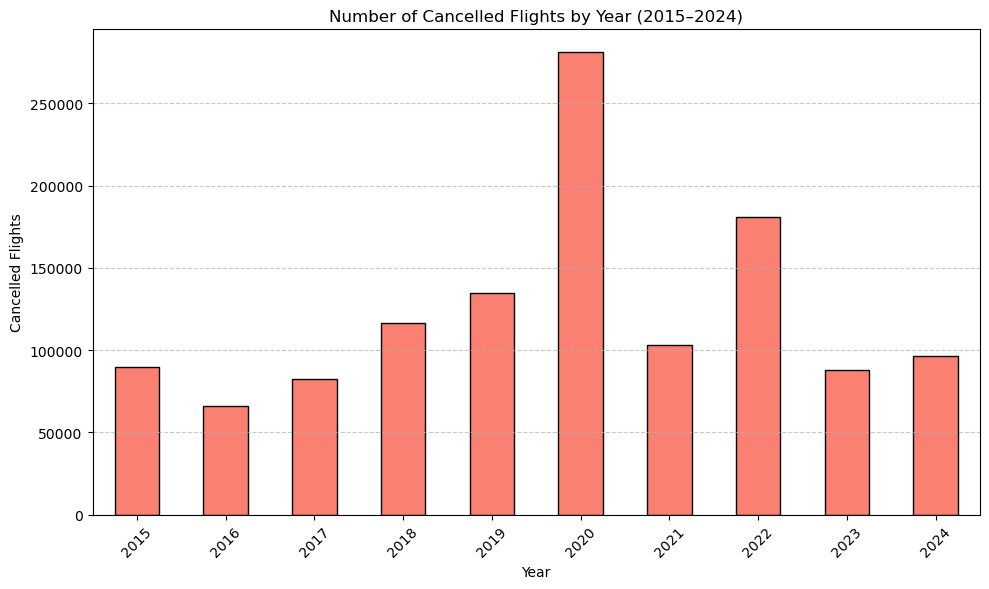

In [42]:
# Filter only cancelled flights
cancelled_df = df[df['CANCELLED'] == True]

# Count cancelled flights per year
cancelled_by_year = cancelled_df['YEAR'].value_counts().sort_index()

# Plot bar chart
plt.figure(figsize=(10, 6))
cancelled_by_year.plot(kind='bar', color='salmon', edgecolor='black')

plt.title('Number of Cancelled Flights by Year (2015–2024)')
plt.xlabel('Year')
plt.ylabel('Cancelled Flights')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

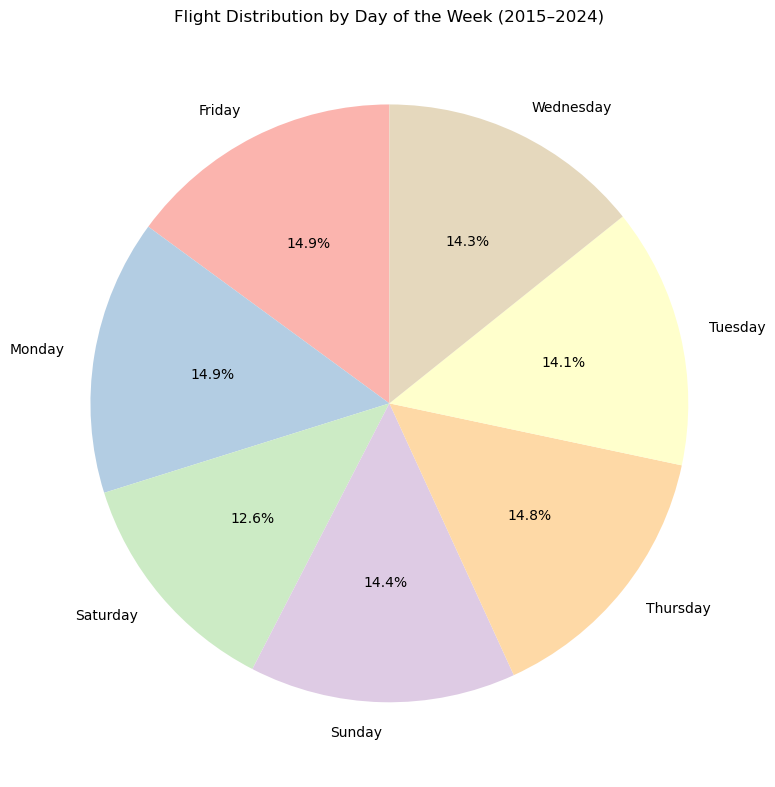

In [43]:
# Map day numbers to names
day_names = {
    1: 'Monday', 2: 'Tuesday', 3: 'Wednesday', 4: 'Thursday',
    5: 'Friday', 6: 'Saturday', 7: 'Sunday'
}
df['DayName'] = df['DAY_OF_WEEK'].map(day_names)

# Count flights by day of the week
day_counts = df['DayName'].value_counts().sort_index()

# Plot pie chart
plt.figure(figsize=(8, 8))
plt.pie(day_counts,
        labels=day_counts.index,
        autopct='%1.1f%%',
        startangle=90,
        colors=plt.cm.Pastel1.colors)

plt.title('Flight Distribution by Day of the Week (2015–2024)')
plt.tight_layout()
plt.show()

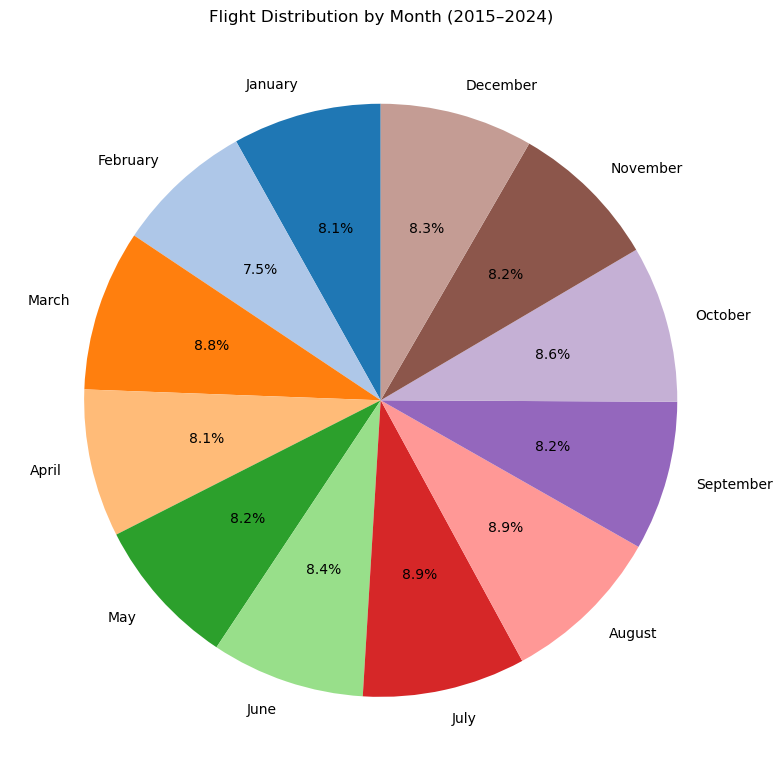

In [45]:
# Count flights by month (across all years)
month_counts = df['MONTH'].value_counts().sort_index()

# Optional: map month numbers to names
month_names = {
    1: 'January', 2: 'February', 3: 'March', 4: 'April',
    5: 'May', 6: 'June', 7: 'July', 8: 'August',
    9: 'September', 10: 'October', 11: 'November', 12: 'December'
}
month_counts.index = month_counts.index.map(month_names)

# Plot pie chart
plt.figure(figsize=(8, 8))
plt.pie(month_counts,
        labels=month_counts.index,
        autopct='%1.1f%%',
        startangle=90,
        colors=plt.cm.tab20.colors)

plt.title('Flight Distribution by Month (2015–2024)')
plt.tight_layout()
plt.show()

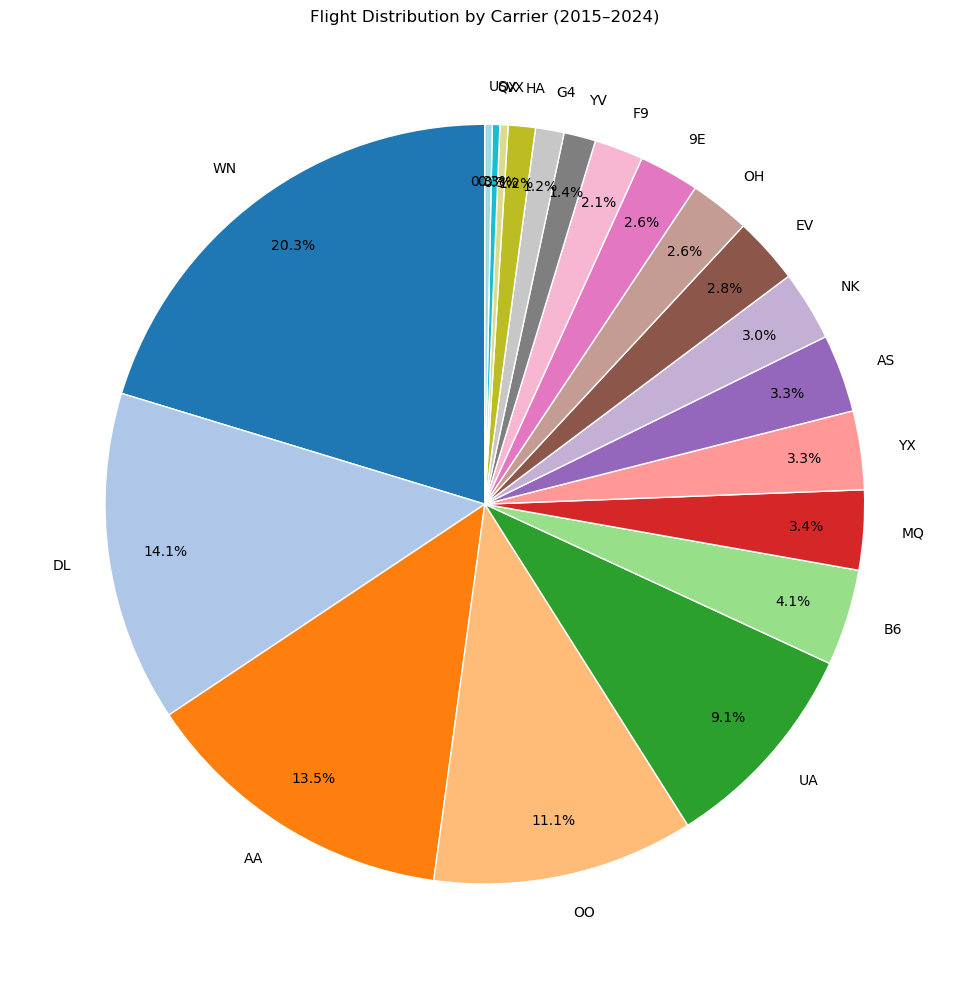

In [47]:
# Count flights by carrier
carrier_counts = df['OP_UNIQUE_CARRIER'].value_counts()

# Optional: map carrier codes to full names (if available)
# carrier_names = {
#     'AA': 'American Airlines',
#     'DL': 'Delta Air Lines',
#     'UA': 'United Airlines',
#     ...
# }
# df['CarrierName'] = df['OP_UNIQUE_CARRIER'].map(carrier_names)
# carrier_counts = df['CarrierName'].value_counts()

# Plot pie chart
plt.figure(figsize=(10, 10))
plt.pie(carrier_counts,
        labels=carrier_counts.index,
        autopct='%1.1f%%',
        startangle=90,
        pctdistance=0.85,
        wedgeprops={'edgecolor': 'white'},
        colors=plt.cm.tab20.colors)

plt.title('Flight Distribution by Carrier (2015–2024)')
plt.tight_layout()

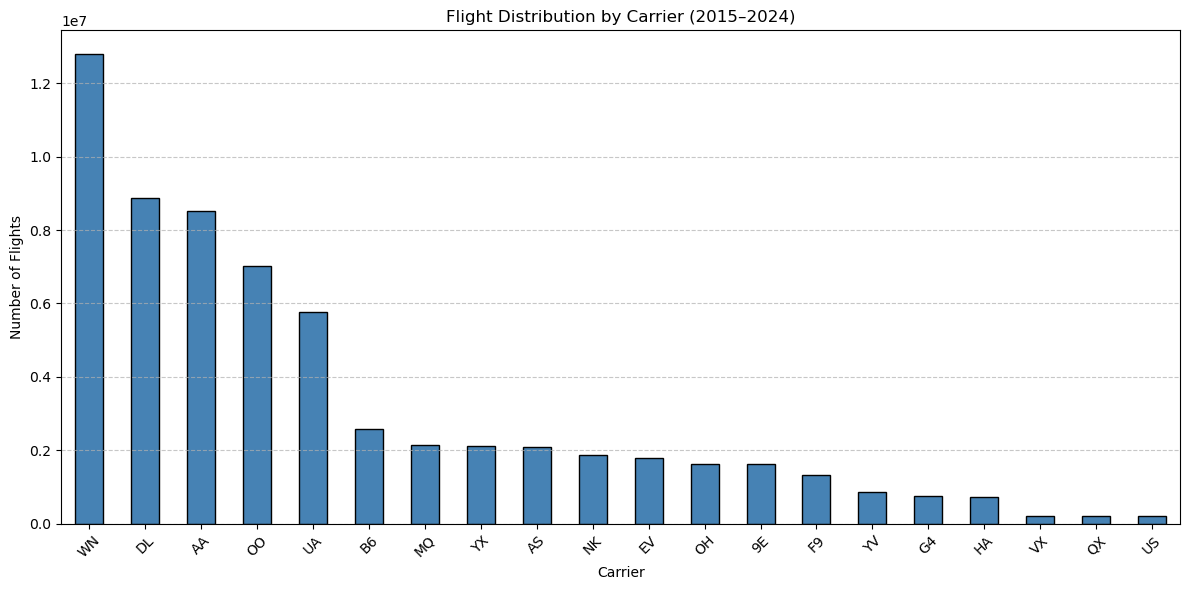

In [48]:
# Count flights by carrier
carrier_counts = df['OP_UNIQUE_CARRIER'].value_counts().sort_values(ascending=False)

# Plot bar chart
plt.figure(figsize=(12, 6))
carrier_counts.plot(kind='bar', color='steelblue', edgecolor='black')

plt.title('Flight Distribution by Carrier (2015–2024)')
plt.xlabel('Carrier')
plt.ylabel('Number of Flights')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()